In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv(r"C:\Users\Pratyasha\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\643A87665E0F1D7423C24B92A1CC40E241B2C36D\transfers\2026-15\naive_bayes_10000_dataset.csv")
df.info

<bound method DataFrame.info of       gender  cgpa  attendance internship  projects communication  \
0       Male  7.19       79.99        Yes         1        Medium   
1     Female  7.54       89.87        Yes         3          High   
2       Male  9.17       82.51         No         3        Medium   
3       Male  6.96       63.33         No         1        Medium   
4       Male  9.24       67.42        Yes         4           Low   
...      ...   ...         ...        ...       ...           ...   
9995  Female  8.30       73.10        Yes         2          High   
9996    Male  6.26       89.08        Yes         2           Low   
9997  Female  5.72       96.93        Yes         1          High   
9998  Female  8.44       85.49         No         4           Low   
9999    Male  6.58       98.07         No         3          High   

      aptitude_score  coding_score  backlogs extracurricular  placed  
0                 84            63         2              No       0

In [23]:
df.isnull().sum()

gender             0
cgpa               0
attendance         0
internship         0
projects           0
communication      0
aptitude_score     0
coding_score       0
backlogs           0
extracurricular    0
placed             0
dtype: int64

In [24]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
le = LabelEncoder()
categorical_cols = ['internship', 'extracurricular']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
df['communication'] = df['communication'].str.strip()
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['communication'] = df['communication'].map(mapping)
print(df['communication'].value_counts())

communication
1    3955
0    3056
2    2989
Name: count, dtype: int64


In [26]:
X = df.drop('placed', axis=1)
y = df['placed']

In [27]:
df.info

<bound method DataFrame.info of       gender  cgpa  attendance  internship  projects  communication  \
0          0  7.19       79.99           1         1              1   
1          1  7.54       89.87           1         3              2   
2          0  9.17       82.51           0         3              1   
3          0  6.96       63.33           0         1              1   
4          0  9.24       67.42           1         4              0   
...      ...   ...         ...         ...       ...            ...   
9995       1  8.30       73.10           1         2              2   
9996       0  6.26       89.08           1         2              0   
9997       1  5.72       96.93           1         1              2   
9998       1  8.44       85.49           0         4              0   
9999       0  6.58       98.07           0         3              2   

      aptitude_score  coding_score  backlogs  extracurricular  placed  
0                 84            63         

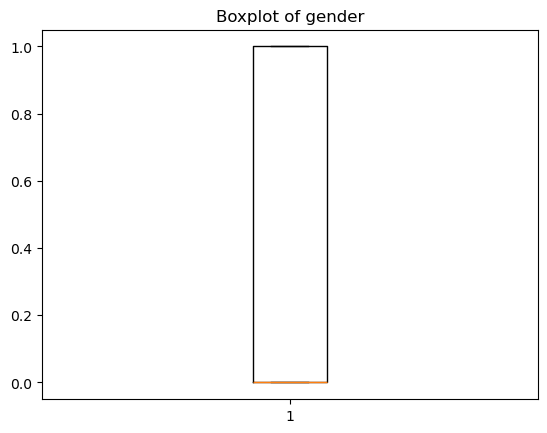

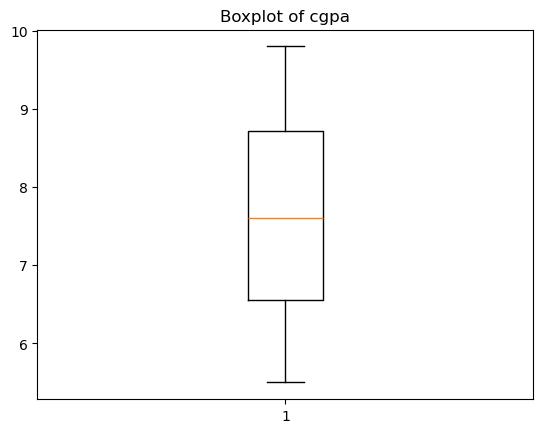

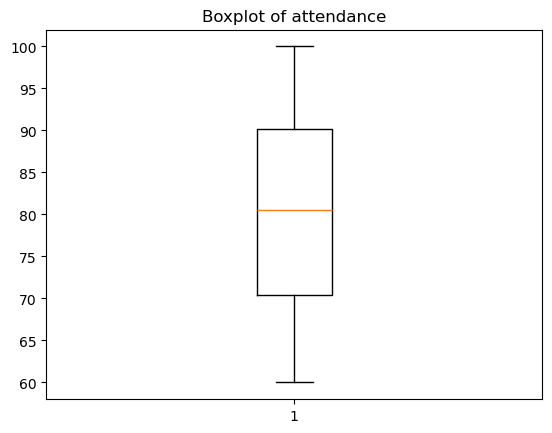

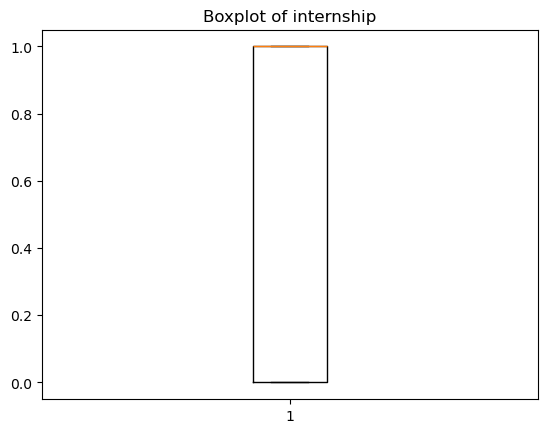

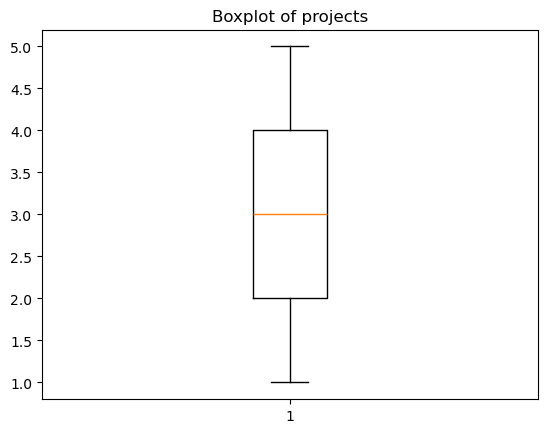

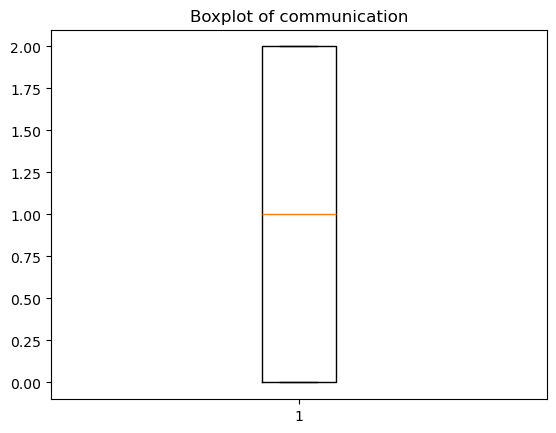

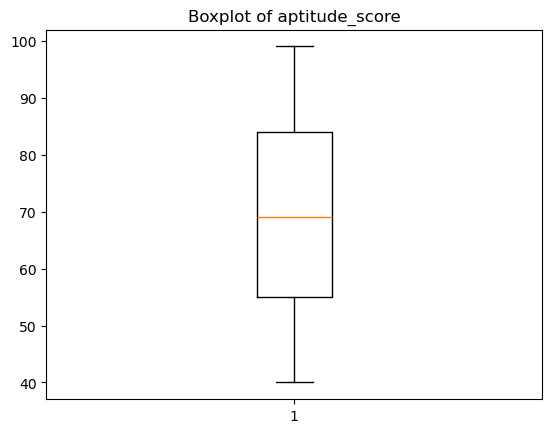

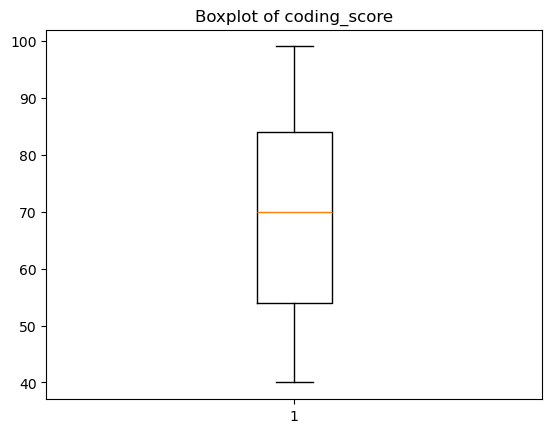

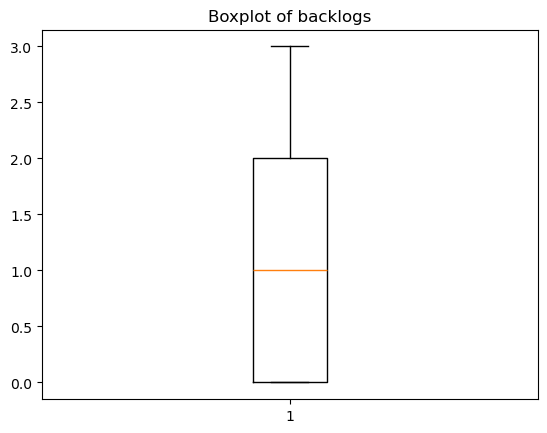

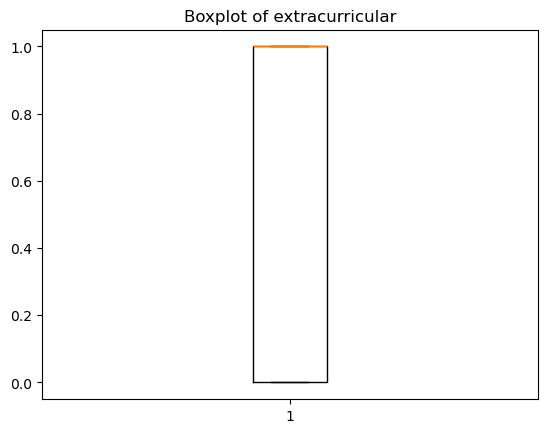

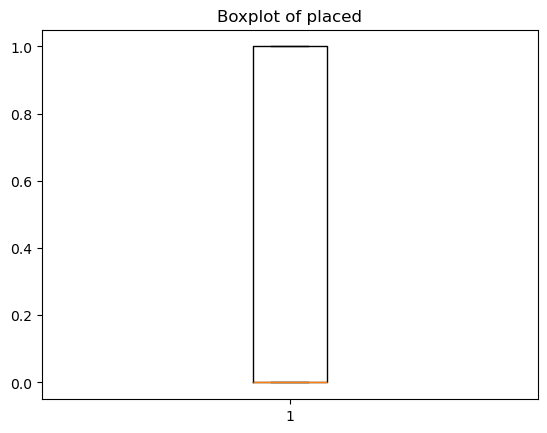

In [28]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8855


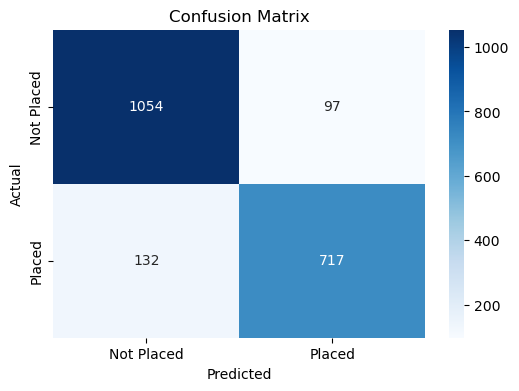

In [30]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

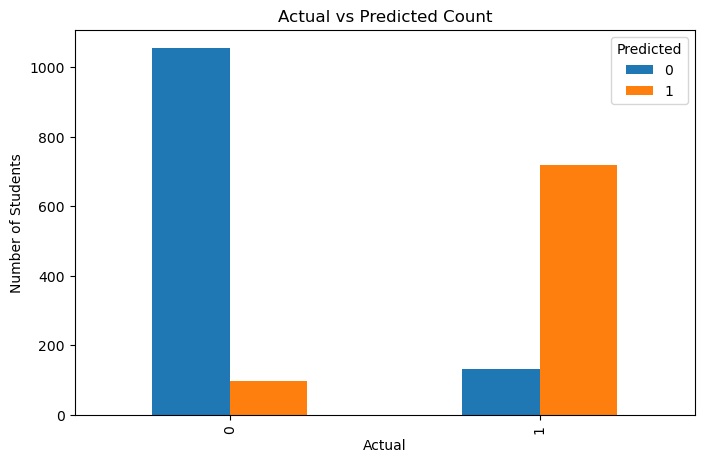

In [32]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.value_counts().unstack().plot(kind='bar', figsize=(8,5))
plt.title('Actual vs Predicted Count')
plt.ylabel('Number of Students')
plt.show()